In [1]:
import pandas as pd

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv('tendulkar_ODI.csv', index_col=0)
df.head()

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,Start Date
1,0,-,2,0,0,0,5,caught,2,v Pakistan,Gujranwala,18-Dec-89
2,0,2,2,0,0,0,5,caught,2,v New Zealand,Dunedin,1-Mar-90
3,36,51,39,5,0,92.3,6,caught,1,v New Zealand,Wellington,6-Mar-90
4,19,38,35,1,1,54.28,4,bowled,2,v England,Leeds,18-Jul-90
5,31,31,26,3,0,119.23,6,bowled,2,v England,Nottingham,20-Jul-90


In [22]:
df.shape

(295, 12)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295 entries, 1 to 295
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Runs        295 non-null    str  
 1   Mins        295 non-null    str  
 2   BF          295 non-null    str  
 3   4s          295 non-null    str  
 4   6s          295 non-null    str  
 5   SR          295 non-null    str  
 6   Pos         295 non-null    str  
 7   Dismissal   295 non-null    str  
 8   Inns        295 non-null    str  
 9   Opposition  295 non-null    str  
 10  Ground      295 non-null    str  
 11  Start Date  295 non-null    str  
dtypes: str(12)
memory usage: 27.8 KB


In [24]:
df['Runs'].value_counts().sort_index()


Runs
0       12
1       16
10       3
100      3
100*     2
        ..
96*      1
97       1
99       2
DNB      2
TDNB     1
Name: count, Length: 118, dtype: int64

In [25]:
df['Runs'] = df['Runs'].replace('DNB', 0)
df['Runs'] = df['Runs'].replace('TDNB', 0)
df['Runs'] = df['Runs'].apply(lambda x: x[:-1] if isinstance(x, str) and x.endswith('*') else x)

In [29]:
df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce')
df['Runs'].value_counts().sort_index()


Runs
0      15
1      16
2      14
3       6
4       9
       ..
146     1
163     1
175     1
186     1
200     1
Name: count, Length: 105, dtype: int64

In [30]:
bins = [0, 10, 20, 30, 40, float('inf')]
labels = ['0-10', '10-20', '20-30', '30-40', '40+']

df_runs_bucket = (
    pd.cut(df['Runs'], bins=bins, labels=labels, right=False)
    .value_counts()
    .sort_index()
    .reset_index(name='Frequency')
    .rename(columns={'index': 'Runs Bucket'})
)
df_runs_bucket

,Runs,Frequency
0,0-10,87
1,10-20,38
2,20-30,31
3,30-40,35
4,40+,104


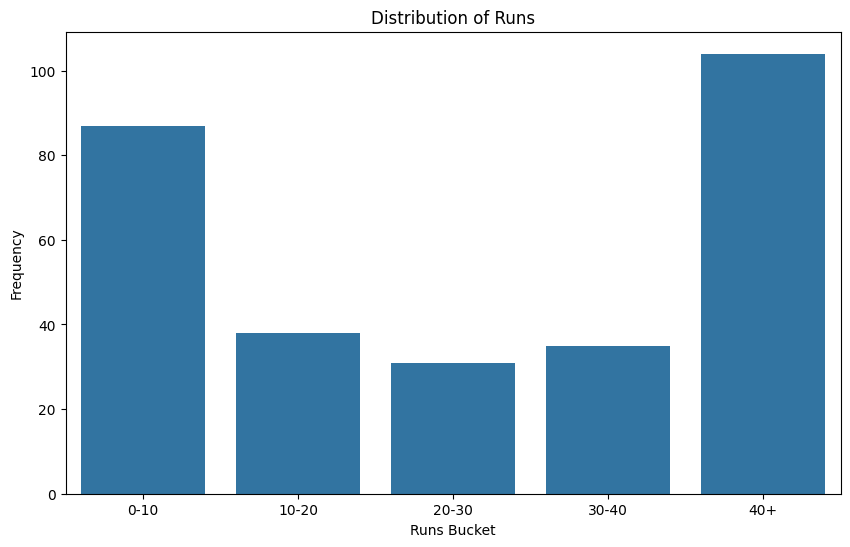

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Runs', y='Frequency', data=df_runs_bucket)
plt.title('Distribution of Runs')
plt.xlabel('Runs Bucket')
plt.ylabel('Frequency')
plt.show()

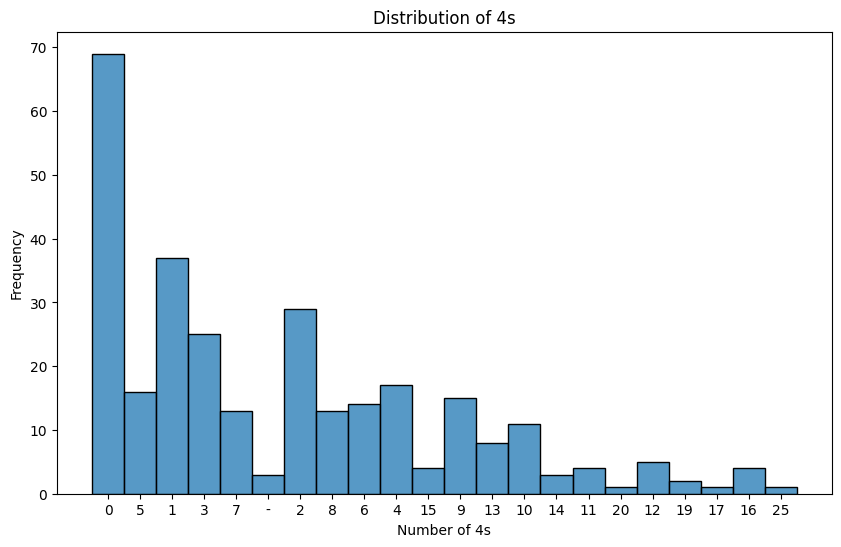

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(df['4s'], bins=20, kde=False)
plt.title('Distribution of 4s')
plt.xlabel('Number of 4s')
plt.ylabel('Frequency')
plt.show()